In [38]:
import pandas as pd
import numpy as np

In [39]:
df = pd.read_csv("powerplant_data.csv")

In [40]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [41]:
# here ->>>
# AT = tempearture
#V = vaccum
#AP = pressure
#RH = humidity
#PE = produced energy

In [42]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [43]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [44]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [45]:
#split out data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
    )

In [46]:
df.shape

(9568, 5)

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [49]:
# Convert data into Tensor
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [50]:
#type(X_train_scaled)

In [51]:
#type(y_train)

In [52]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [53]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset , batch_size=32, shuffle=False)

In [54]:
## Deeplearning work****
## Build an ANN

In [55]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model = nn.Sequential(
        #1st Hidden layer

        #nn.Linear(input feature , output feature)
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        #2nd Hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #3rd Hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1),
        )

  def forward(self,x):
      return self.model(x)

In [56]:
import torch.optim as optim

model = ANN()
#loss fnx
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


In [57]:
# Train the ANN

In [58]:
train_losses = []
val_losses = []

best_val_loss = float("inf")  # INF = INFINITY

epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0# total traing loss for 1 epoch

  for xb,yb in train_loader:
    #xb = feature of 1 batch
    #yb = label of 1 batch

    optimizer.zero_grad() # reset gradient to zero

    outputs = model(xb)  # forward propagation.....predict output for this batch
    loss = crietrion(outputs,yb) #  compute loss
    loss.backward() # back  prop..... compute gradient
    optimizer.step() # param update

    running_loss += loss.item() # loss is a tensor value  =>> thats why we use .item to convert it into py float

  epoch_train_loss = running_loss/len(train_loader)
  train_losses.append(epoch_train_loss)


  # Validation
  model.eval()
  running_val_loss = 0.0

  with torch.no_grad():
    for xb,yb in test_loader:
      outputs = model(xb)
      loss = crietrion(outputs,yb)
      running_val_loss += loss.item()

  epoch_val_loss = running_val_loss/len(test_loader)
  val_losses.append(epoch_val_loss)

  print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss} ")


  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(), "best_model.pt") # .pt or .ph






epoch 1/100 ==> train loss = 204929.88287760416 & val loss = 198766.26692708334 
epoch 2/100 ==> train loss = 167885.95540364584 & val loss = 116737.13359375 
epoch 3/100 ==> train loss = 60409.86977945964 & val loss = 25899.690185546875 
epoch 4/100 ==> train loss = 17737.13946126302 & val loss = 12584.009497070312 
epoch 5/100 ==> train loss = 10303.634983317057 & val loss = 7662.374593098958 
epoch 6/100 ==> train loss = 6255.376532999674 & val loss = 4521.091001383464 
epoch 7/100 ==> train loss = 3618.006298319499 & val loss = 2563.8329610188803 
epoch 8/100 ==> train loss = 2068.3580492655437 & val loss = 1506.374178059896 
epoch 9/100 ==> train loss = 1256.3874656677247 & val loss = 976.912260945638 
epoch 10/100 ==> train loss = 832.5638182322184 & val loss = 679.7726155598958 
epoch 11/100 ==> train loss = 588.9923173268636 & val loss = 498.7474304199219 
epoch 12/100 ==> train loss = 434.18261121114097 & val loss = 377.97677688598634 
epoch 13/100 ==> train loss = 324.3236888

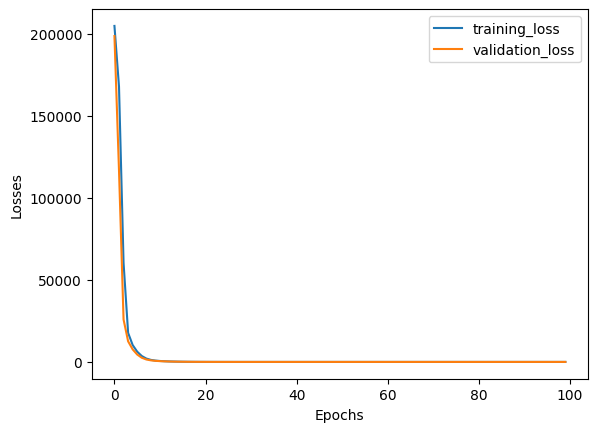

In [62]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "training_loss": train_losses,
    "validation_loss": val_losses
})

plt.plot(loss_df["training_loss"], label="training_loss")
plt.plot(loss_df["validation_loss"], label="validation_loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()


In [63]:
# load the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [64]:
# Evaluation

model.eval()
with torch.no_grad():
  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)

  train_mse_loss = crietrion(train_pred , y_train_tensor)
  test_mse_loss = crietrion(test_pred , y_test_tensor)

print(f"Training MSE Loss = {train_mse_loss.item()}")
print(f"Testing MSE Loss = {test_mse_loss.item()}")


Training MSE Loss = 21.099016189575195
Testing MSE Loss = 19.534969329833984


In [65]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test , test_pred))

r^2 score = 0.9317303291260901


In [66]:
predicted_df = pd.DataFrame(test_pred.numpy() , columns=["Predicted Value"])
actual_df = pd.DataFrame(y_test.values , columns=["Actual Values"])

pd.concat([predicted_df , actual_df],axis=1)

,Predicted Value,Actual Values
0,435.683533,433.27
1,437.582977,438.16
2,461.285767,458.42
3,476.101715,480.82
4,435.790741,441.41
...,...,...
1909,451.595062,456.70
1910,432.248260,438.04
1911,467.472076,467.80
1912,431.746216,437.14
